This notebook takes the outputs of simulations run by the [Coupled Model Intercomparison Project](https://wcrp-cmip.org/) (CMIP) and compares simulations of Earth's climate with and without human climate forcing. The code in this notebook is based on the following sources:

 * https://earth-env-data-science.github.io/lectures/models/cmip.html
 * https://ecmwf-projects.github.io/copernicus-training-c3s/projections-cmip6.html

It retrieves climate model run outputs maintained by the [Pangeo community](https://pangeo.io/) stored on Google Cloud Storage using a specialized api.

We use this to compare surface air temperatures given by climate simulations with and without human emissions.

In [1]:
from xmip.preprocessing import combined_preprocessing
from xmip.utils import google_cmip_col
from xmip.postprocessing import match_metrics
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Initialize and examine
col = google_cmip_col()
col

,unique
activity_id,18
institution_id,36
source_id,88
experiment_id,170
member_id,657
table_id,37
variable_id,700
grid_label,10
zstore,514818
dcpp_init_year,61


We have access to 514818 model runs, divided into 170 experiments. We will focus on the following experiments (see https://clipc-services.ceda.ac.uk/dreq/index/experiment.html)
 * `historical`
   * **description:** Simulation of recent past (1850 to 2014). Impose changing conditions (consistent with observations). Should be initialised from a point early enough in the pre-industrial control run to ensure that the end of all the perturbed runs branching from the end of this historical run end before the end of the control. Only one ensemble member is requested but modelling groups are strongly encouraged to submit at least three ensemble members of their CMIP historical simulation.
 * `hist-nat`
   * **description:** Historical natural-only simulations resemble the historical simulations but instead are forced with only solar and volcanic forcing from the historical simulations. Report what sets of emissions and boundary conditions are used.
  
In other words, `historical` simulations use all known data, while `hist-nat`simulations omit human-caused climate forcings.

All models are required to submit at least three runs with different configurations. Certain models have more than three initial configuration. We will want to use three configurations per model.

In [3]:
# The initializations we will be using.
member_ids = ['r1i1p1f1','r2i1p1f1','r3i1p1f1']

In [4]:
#Get runs for hist-nat
nats = col.search(
    variable_id='tas', # air surface temperature
    experiment_id='hist-nat',
    grid_label='gn', #by longitude and lattitude
    member_id=member_ids #keep the three common initializations for each model 
)

More models have been used for `historical`simulations than `hist-nat`. For our comparison, we'll only take the models from `historical` runs that have been used in natural runs.

In [5]:
hists = col.search(
    variable_id='tas', # air surface temperature
    experiment_id='historical',
    grid_label='gn',
    table_id='Amon',
    source_id=list(nats.df['source_id']), #We only keep the models used in hist-nat
    member_id=member_ids
)

Let's verify that our that we have the same models in both cases.

In [6]:
nats

,unique
activity_id,1
institution_id,9
source_id,9
experiment_id,1
member_id,3
table_id,1
variable_id,1
grid_label,1
zstore,27
dcpp_init_year,1


In [7]:
hists

,unique
activity_id,1
institution_id,9
source_id,9
experiment_id,1
member_id,3
table_id,1
variable_id,1
grid_label,1
zstore,27
dcpp_init_year,1


We see that in both queries we have a total of 27 runs (see the **zstore** entry.) We can even check that the same models are used.

In [8]:
getMods = lambda x : list(x.df['source_id'].unique())
hmods = getMods(hists)
hmods.sort()
nmods = getMods(nats)
nmods.sort()
print('Kept Models in historical runs:')
print(hmods)
print('Kept Models in hist-nat runs:')
print(nmods)

Kept Models in historical runs:
['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CESM2', 'CanESM5', 'FGOALS-g3', 'MIROC6', 'MRI-ESM2-0', 'NorESM2-LM']
Kept Models in hist-nat runs:
['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CESM2', 'CanESM5', 'FGOALS-g3', 'MIROC6', 'MRI-ESM2-0', 'NorESM2-LM']


We can also query the institutions that ran the models.

In [9]:
print(list(hists.df['institution_id'].unique()))
print(list(nats.df['institution_id'].unique()))

['BCC', 'MIROC', 'MRI', 'NCAR', 'CCCma', 'NCC', 'CAS', 'CSIRO-ARCCSS', 'CSIRO']
['MRI', 'BCC', 'CCCma', 'NCAR', 'NCC', 'MIROC', 'CAS', 'CSIRO', 'CSIRO-ARCCSS']


Looking up institution codes here https://wcrp-cmip.github.io/CMIP6_CVs/docs/CMIP6_institution_id.html we see that our ensemble includes models that were run in the following countries:

 * China
 * Japan
 * USA
 * Canada
 * Norway
 * Australia

We'll now retrieve the data. The preprocessing makes sure all the variables have common names, so that we can work in batches.

In [10]:
# Retrieve the data this will take some time.
nddicts = nats.to_dataset_dict(preprocess=combined_preprocessing,xarray_open_kwargs={'use_cftime':True})
hddicts = hists.to_dataset_dict(preprocess=combined_preprocessing,xarray_open_kwargs={'use_cftime':True})


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'



--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


/home/nick/throwaway/foo/.venv/lib/python3.13/site-packages/intake_esm/source.py:298: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  self._ds = xr.combine_by_coords(


Let's look at what was downloaded. We'll take the very first entry of the very first `hist-nat`run.

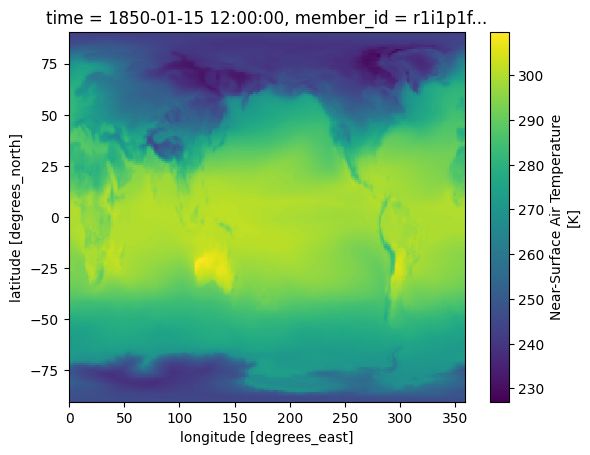

In [11]:
ensemble1 = nddicts[list(nddicts.keys())[0]] #First modelling the downloaded natural runs
ensemble11 = ensemble1.isel(member_id=0) #First run of that model
tas11 = ensemble11['tas'] # the variable we're interested, TAS = surface air temperature
tas110=tas11.isel(time=0) #Surface temperatures at the beginning of that run
tas110.plot() #This may take some time

We see that the data we downloaded consists of temperature values for each point on Earth, given by lattitude and longitude calculated by the simulations. Such heatmaps are given at monthly intervals. What we want to do is to take all those heat maps and calculate the average temperature of the world, then take averages every month to produce an annual time series of average temperature for each of our 27 runs per experiment.

A bit of math is needed because the areas of longitude/latitude grids get distorted at high latitudes.

In [12]:
def getRuns(ddict):
    """
    Takes ddicts and returns the a list of average annual surface temperatures of each individual run
    """
    runs = []
    for name, ds in ddict.items():
        for m in member_ids:
            #print(f"     {name}     {m}")#debug
            run = ds.sel(member_id=m)
            run = run['tas']
            # construct yearly global mean timeseries
            # Weight data by lattitude
            weights = np.cos(np.deg2rad(run.y)) #correct for lattitude distortion
            weights.name='weights'
            run_weighted = run.weighted(weights)
            # Spatially and temporally aggregate data
            run_mean_annual = run_weighted.mean(['x', 'y']).coarsen(time=12).mean()
            # Add run to list
            runs.append(run_mean_annual)
    return runs

In [13]:
nruns = getRuns(nddicts)
hruns = getRuns(hddicts)

Models take a lot of computing time to run. Not all of our models go up to the same year, so we'll truncate our time series so they all have the same number of years.

In [14]:
minyears = 200
for r in nruns:
    if r.shape[1] < minyears:
        minyears = r.shape[1]
for i in hruns:
    if r.shape[1] < minyears:
        minyears = r.shape[1]
print(f"All runs cover the first {minyears} years after 1850")

All runs cover the first 165 years after 1850


At this point, we've broken down out data into very simple pieces (length 165 time series). We'll pass to a more basic data structure (`numpy` arrays) that will make it easier for me to plot things the way I want.

In [15]:
# Convert everything to numpy and do some final processing.
def numpify(r):
    """
    Converts a an annual average temperature run r to a basic numpy array
    """
    n = r.to_numpy()
    return n.reshape(n.shape[1]) #Pops out a silly dimension

cutToMin = lambda x,y: x[0:y]
reduce = lambda x : cutToMin(numpify(x),minyears)
reduce_l = lambda x: list(map(reduce,x))
average_runs = lambda x: np.mean(x, axis=0)

In [16]:
hruns_n=list(map(reduce,hruns))
hruns_mean = average_runs(hruns_n) #Represents the average values of all historical runs
nruns_n=list(map(reduce,nruns))
nruns_mean = average_runs(nruns_n) #Represents the average values of all hist-nat runs

We want temperature anomalies, so we need to take the difference with a baseline temperature: the average temperature from 1861 to 1890.

In [17]:
# Getting the baseline temperature
allmeans = (hruns_mean+nruns_mean)/2
reference_temps = allmeans[11:40] #years 1861-1890 (year 0 is 1860)
baseline = reference_temps.mean()

# Subtract to get anomalies
hruns_n -= baseline
hruns_mean -= baseline
nruns_n -= baseline
nruns_mean -= baseline

For completeness, below, we'll manually input the historical data from here: https://ourworldindata.org/grapher/temperature-anomaly

In [18]:
# The entries of the 'Global average temperature anomaly relative to 1861-1890' column of the downloaded spreadsheet.
anomalies = [
-0.055067, 0.1615800, 0.14512700, 0.13543700, 0.2061400, 0.13525500, 0.04728800, -0.07056700, 0.022225000, 0.1330460, -0.07820300, -0.024384000, -0.32068300, 0.07966900, -0.08087100, 0.013526000, 0.007046000, -0.024325000, 0.02238400, 0.13202300, 0.06868800, -0.0600900, 0.023670000, 0.0053050000, 0.08709700, -0.10289300, -0.05413700, 0.27946700, 0.45204000, 0.044581000, -0.0031680000, 0.09677900, 0.007850000, -0.046234000, -0.25363200, -0.12880700, -0.064637, -0.11339000, 0.00838000, 0.12036300, -0.14284300, -0.031073000, -0.19523100, -0.17589400, -0.061767000, -0.06429100, 0.087389, 0.12926900, -0.049618000, 0.047784000, 0.18289900, 0.16592200, -0.079038000, -0.12423100, -0.19744300, -0.022677000, 0.120518000, -0.15572700, -0.09693300, -0.11278100, -0.11040300, -0.07211400, -0.1492350, -0.11363300, 0.111981000, 0.20557400, -0.062366000, -0.20339000, -0.08821600, 0.008889000, 0.07203200, 0.21793900, 0.078594000, 0.1259220, 0.18856100, 0.21273400, 0.37933700, 0.27445400, 0.29389200, 0.04474200, 0.35081700, 0.42669200, 0.34339600, 0.11577800, 0.3274270, 0.2942790, 0.3198340, 0.5025950, 0.5403170, 0.43422000, 0.50281000, 0.45632000, 0.44097000, 0.49330700, 0.60089500, 0.46436400, 0.3693550, 0.42503900, 0.38005100, 0.3133170, 0.18993700, 0.4346790, 0.45064700, 0.5874080, 0.34971200, 0.25524200, 0.101700000, 0.3450620, 0.463525, 0.427905, 0.3812260, 0.37409900, 0.42903500, 0.4511940, 0.11982700, 0.18569700, 0.2918690, 0.34169700, 0.24159100, 0.28049100, 0.25832900, 0.15186600, 0.13094600, 0.40243100, 0.13119600, 0.2699470, 0.12896700, 0.4598000, 0.36893300, 0.41191000, 0.5201360, 0.72079300, 0.37095100, 0.5730430, 0.35120800, 0.32880200, 0.4428470, 0.5765440, 0.69649000, 0.59819700, 0.84481600, 0.7660200, 0.4777390, 0.5732740, 0.704055, 0.9494650, 0.6725780, 0.9155500, 1.0951200, 0.85719200, 0.8679050, 1.0090720, 1.0495430, 1.1013010, 1.0143190, 1.2122290, 1.1755900, 1.2129320, 1.0525340, 1.0875690, 1.300329, 1.1061750, 1.1651610, 1.1575040, 1.2886230, 1.51167, 1.6360220, 1.4962260, 1.340491, 1.5245730, 1.6567390, 1.459022, 1.4806310, 1.7946950, 1.9299380, 1.9375350
]

Finally we can plot all our data. Indivudual runs appear as faint lines, the averages are thick lines. We also include the historical anomaly in the plot.

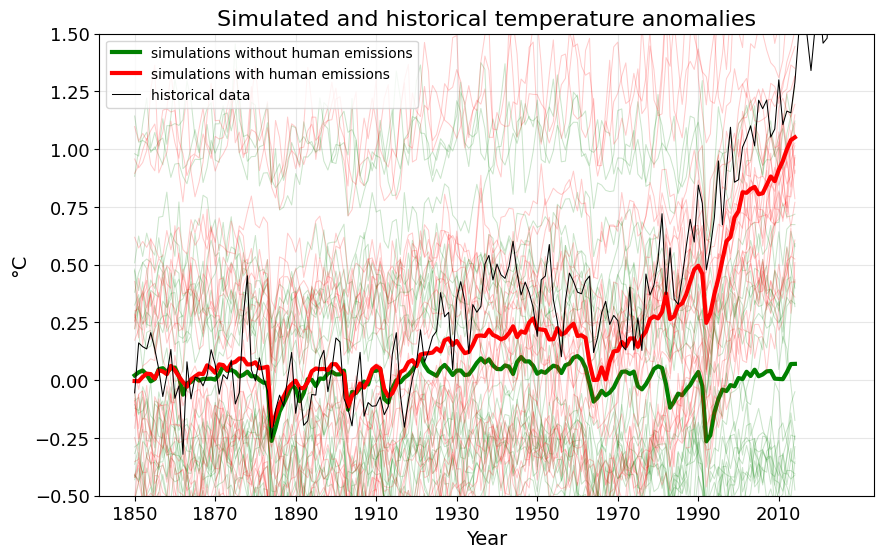

In [19]:
#Building the final plot
fontsize=14

#Getting historical anomaly
anomsalies = anomalies
#Drawing the whole thing
plt.figure(figsize=(10,6))
#Draw
for i in nruns_n:
    plt.plot(i, color='green', alpha=0.2, linewidth=0.75)
plt.plot(nruns_mean,color='green',linewidth=3,label='simulations without human emissions')

for i in hruns_n:
    plt.plot(i, color='red', alpha=0.2, linewidth=0.75)
plt.plot(hruns_mean,color='red',linewidth=3, label='simulations with human emissions')

plt.plot(anomalies, color='black', linewidth=0.75, label='historical data')

# Get years correct
plt.xticks(range(0,166,20),range(1850,2016,20))
#plt.grid(True, alpha=0.3)  # For a fainter grid
plt.ylim(-0.5, 1.5) 
plt.xlabel('Year',fontsize='14')
plt.ylabel('°C',fontsize='14')
plt.title('Simulated and historical temperature anomalies',fontsize=fontsize+2) #title slightly larger
plt.xticks(fontsize=fontsize - 1)  # Tick labels slightly smaller
plt.yticks(fontsize=fontsize - 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('Simluated and natural runs', dpi=300, bbox_inches='tight')
plt.show()